In [36]:
import sys
print(sys.executable)

import pandas, sklearn
print(pandas.__version__, sklearn.__version__)

/Users/alexandraevans/Comp/credit_fraud/venv/bin/python
2.3.3 1.7.2


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv('../data/raw/creditcard.csv')
df.shape

df.columns.to_list()


['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [39]:
df['Class'].value_counts(normalize=True)

#df.info()

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [40]:
df.duplicated().sum()


np.int64(1081)

In [41]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [42]:
print(df['Time'].head())

print(df['Time'].min()) 
print(df['Time'].max())


0    0.0
1    0.0
2    1.0
3    1.0
4    2.0
Name: Time, dtype: float64
0.0
172792.0


In [43]:
df['hour_of_day'] = (df['Time'] % 86400) // 3600
print(df[['Time', 'hour_of_day']].head())

   Time  hour_of_day
0   0.0          0.0
1   0.0          0.0
2   1.0          0.0
3   1.0          0.0
4   2.0          0.0


In [44]:
print(df['hour_of_day'].unique())

df.groupby('hour_of_day')['Class'].mean()

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23.]


hour_of_day
0.0     0.000780
1.0     0.002370
2.0     0.017127
3.0     0.004868
4.0     0.010412
5.0     0.003679
6.0     0.002195
7.0     0.003175
8.0     0.000876
9.0     0.001010
10.0    0.000482
11.0    0.003144
12.0    0.001102
13.0    0.001106
14.0    0.001388
15.0    0.001579
16.0    0.001337
17.0    0.001794
18.0    0.001937
19.0    0.001214
20.0    0.001074
21.0    0.000904
22.0    0.000583
23.0    0.001920
Name: Class, dtype: float64

In [45]:
df.groupby('hour_of_day')['Class'].sum()

hour_of_day
0.0      6
1.0     10
2.0     57
3.0     17
4.0     23
5.0     11
6.0      9
7.0     23
8.0      9
9.0     16
10.0     8
11.0    53
12.0    17
13.0    17
14.0    23
15.0    26
16.0    22
17.0    29
18.0    33
19.0    19
20.0    18
21.0    16
22.0     9
23.0    21
Name: Class, dtype: int64

In [46]:
#all dupicate rows 
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10) 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour_of_day
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0,0.0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0,0.0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0,0.0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0,0.0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0,0.0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0,0.0


In [47]:
df = df.drop_duplicates()
df.shape

(283726, 32)

In [48]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


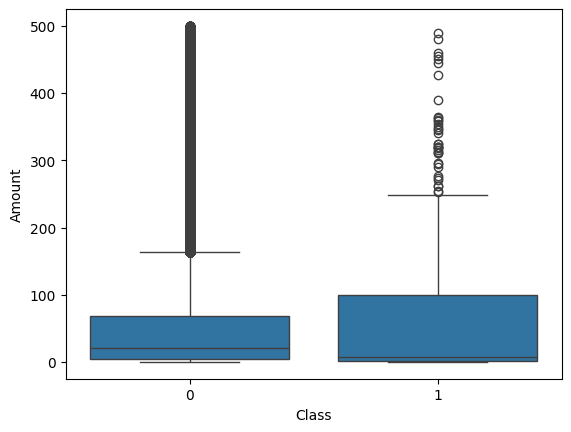

In [49]:
sns.boxplot(x='Class', y='Amount', data=df[df['Amount'] < 500])
plt.show()

In [50]:
# only catches linear relationships
correlations = df.corr()['Class'].sort_values(ascending=False)
correlations

Class          1.000000
V11            0.149067
V4             0.129326
V2             0.084624
V19            0.033631
V8             0.033068
V21            0.026357
V27            0.021892
V20            0.021486
V28            0.009682
Amount         0.005777
V22            0.004887
V26            0.004265
V25            0.003202
V15           -0.003300
V13           -0.003897
V23           -0.006333
V24           -0.007210
Time          -0.012359
hour_of_day   -0.016740
V6            -0.043915
V5            -0.087812
V9            -0.094021
V1            -0.094486
V18           -0.105340
V7            -0.172347
V3            -0.182322
V16           -0.187186
V10           -0.206971
V12           -0.250711
V14           -0.293375
V17           -0.313498
Name: Class, dtype: float64

In [51]:
X = df.drop(columns=['Class'])
y = df['Class']

X.shape, y.shape

((283726, 31), (283726,))

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [53]:
X_train.shape, X_test.shape

((226980, 31), (56746, 31))

In [54]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(Class
 0    0.998335
 1    0.001665
 Name: proportion, dtype: float64,
 Class
 0    0.998326
 1    0.001674
 Name: proportion, dtype: float64)

In [55]:
X_train.filter(like='V').skew()

V1     -3.304103
V2     -4.883896
V3     -2.124559
V4      0.680751
V5     -0.168415
V6      1.194313
V7     -0.891383
V8     -8.008567
V9      0.535307
V10     1.213230
V11     0.351889
V12    -2.202431
V13     0.060812
V14    -2.001202
V15    -0.312237
V16    -1.089745
V17    -3.695050
V18    -0.242588
V19     0.109420
V20    -0.227200
V21     3.437503
V22    -0.212515
V23    -5.774360
V24    -0.554230
V25    -0.421808
V26     0.571032
V27    -2.783690
V28    12.188612
dtype: float64

In [56]:
from sklearn.preprocessing import RobustScaler

cols_to_scale = X_train.columns.to_list()
scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

X_train_scaled.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,hour_of_day
count,226980.000000,226980.000000,226980.000000,2.269800e+05,2.269800e+05,226980.000000,2.269800e+05,226980.000000,2.269800e+05,2.269800e+05,...,2.269800e+05,2.269800e+05,226980.000000,2.269800e+05,2.269800e+05,2.269800e+05,226980.000000,226980.000000,226980.000000,226980.000000
mean,0.118467,-0.005974,-0.049463,-9.201113e-02,1.255679e-02,0.044015,2.349303e-01,-0.034999,-4.202809e-02,4.031268e-02,...,7.178829e-02,-6.866841e-03,0.035958,-5.167418e-02,-2.380088e-02,9.178721e-02,0.001125,-0.079995,0.918890,-0.105070
std,0.557881,0.872721,1.176252,7.872012e-01,8.907940e-01,1.042265,1.134854e+00,1.067395,2.189368e+00,8.833613e-01,...,1.740203e+00,6.766285e-01,2.014884,7.621087e-01,7.798472e-01,8.495508e-01,2.412071,2.479393,3.405863,0.647655
min,-0.996399,-25.288450,-51.895128,-1.768367e+01,-3.558984e+00,-24.560719,-2.219678e+01,-38.774475,-1.371258e+02,-1.080429e+01,...,-8.385150e+01,-1.021956e+01,-144.253529,-3.620168e+00,-1.541592e+01,-4.505273e+00,-139.366693,-89.223071,-0.305987,-1.666667
25%,-0.359179,-0.418701,-0.474124,-5.565134e-01,-5.200782e-01,-0.488053,-4.226226e-01,-0.527684,-4.322513e-01,-4.775868e-01,...,-4.804289e-01,-5.128786e-01,-0.486354,-4.980661e-01,-4.991125e-01,-4.850961e-01,-0.444802,-0.487763,-0.227134,-0.555556
50%,0.000000,0.000000,0.000000,7.248908e-18,-1.090131e-18,0.000000,-2.380163e-17,0.000000,-3.247948e-18,-2.801138e-18,...,4.179578e-18,-4.050935e-19,0.000000,4.364549e-18,-2.593403e-18,6.122354e-18,0.000000,0.000000,0.000000,0.000000
75%,0.640821,0.581299,0.525876,4.434866e-01,4.799218e-01,0.511947,5.773774e-01,0.472316,5.677487e-01,5.224132e-01,...,5.195711e-01,4.871214e-01,0.513646,5.019339e-01,5.008875e-01,5.149039e-01,0.555198,0.512237,0.772866,0.444444
max,1.033522,1.092001,15.682657,4.807100e+00,1.062278e+01,26.718231,1.858179e+01,30.471631,3.741801e+01,1.263434e+01,...,6.561204e+01,9.803975e+00,72.582873,5.000781e+00,1.121771e+01,6.298669e+00,75.039553,257.540705,272.096037,0.888889


In [57]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

print(classification_report(y_test, y_pred_dummy))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.00      0.00      0.00        95

    accuracy                           1.00     56746
   macro avg       0.50      0.50      0.50     56746
weighted avg       1.00      1.00      1.00     56746



/Users/alexandraevans/Comp/credit_fraud/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alexandraevans/Comp/credit_fraud/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alexandraevans/Comp/credit_fraud/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [58]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.97      0.99     56746



In [59]:
# show acutal probs from sklearn before it applied 0.5 threshold
y_proba = logreg.predict_proba(X_test_scaled)
y_proba[:5] #logreg.classes to check field order


array([[0.96149392, 0.03850608],
       [0.97704294, 0.02295706],
       [0.99292357, 0.00707643],
       [0.98617017, 0.01382983],
       [0.85273033, 0.14726967]])

In [60]:
#fraud only
y_proba_fraud = y_proba[:,1]
y_proba_fraud[:5]

array([0.03850608, 0.02295706, 0.00707643, 0.01382983, 0.14726967])

In [61]:
threshold = 0.3
y_pred_custom = (y_proba_fraud >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56651
           1       0.03      0.87      0.05        95

    accuracy                           0.95     56746
   macro avg       0.51      0.91      0.51     56746
weighted avg       1.00      0.95      0.97     56746



In [62]:
from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for t in thresholds:
    y_pred_t = (y_proba_fraud >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"Threshold {t}: precision={p:.3f}, recall={r:.3f}, f1={f1:.3f}")

Threshold 0.1: precision=0.009, recall=0.937, f1=0.018
Threshold 0.2: precision=0.017, recall=0.916, f1=0.034
Threshold 0.3: precision=0.027, recall=0.874, f1=0.051
Threshold 0.4: precision=0.040, recall=0.874, f1=0.076
Threshold 0.5: precision=0.055, recall=0.874, f1=0.103
Threshold 0.6: precision=0.076, recall=0.874, f1=0.139
Threshold 0.7: precision=0.102, recall=0.874, f1=0.183
Threshold 0.8: precision=0.150, recall=0.842, f1=0.255
Threshold 0.9: precision=0.235, recall=0.832, f1=0.367


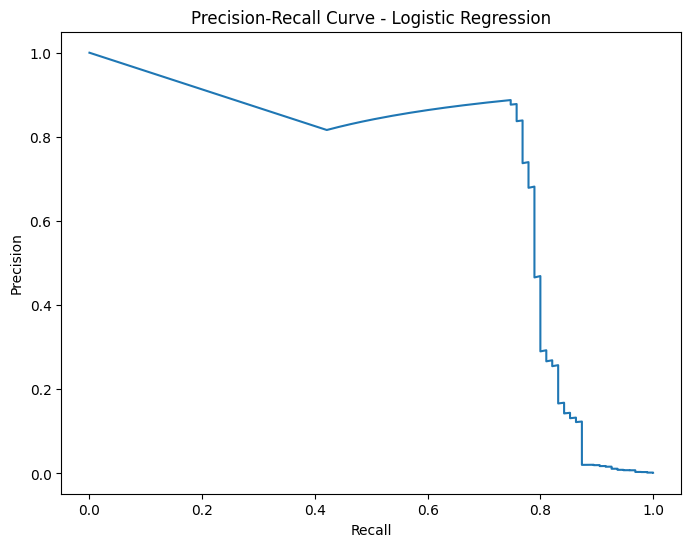

In [63]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba_fraud) # this does automatically, at a much finer resolution, exactly what 9 threshold maunal loop did

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.show()

In [64]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_proba_fraud)
print(f"PR-AUC: {pr_auc: .3f}")

PR-AUC:  0.678


In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [66]:
pr_auc_rf = average_precision_score(y_test, y_proba_rf)
print(f"Random Forest PR-AUC: {pr_auc_rf: .3f}")

Random Forest PR-AUC:  0.814


In [67]:
# classification report needs 0 or 1, not probas
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.69      0.81        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [69]:
# back to using proba vs 0/1 to fine tune
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"Threshold {t}: precision={p:.3f}, recall={r:.3f}, f1={f1:.3f}")

Threshold 0.1: precision=0.837, recall=0.811, f1=0.824
Threshold 0.2: precision=0.936, recall=0.768, f1=0.844
Threshold 0.3: precision=0.946, recall=0.737, f1=0.828
Threshold 0.4: precision=0.958, recall=0.726, f1=0.826
Threshold 0.5: precision=0.971, recall=0.695, f1=0.810
Threshold 0.6: precision=0.984, recall=0.663, f1=0.792
Threshold 0.7: precision=0.983, recall=0.600, f1=0.745
Threshold 0.8: precision=0.981, recall=0.547, f1=0.703
Threshold 0.9: precision=1.000, recall=0.389, f1=0.561
